# Liquidation task: pure exploration EDA

Цель ноутбука - не построить модель и не подобрать финальный фильтр, а спокойно разобраться, что лежит в четырех источниках данных:

- Binance trades
- Binance BBO / booktickers
- Binance liquidations
- Bybit liquidations

Основной принцип: сначала смотрим на форму данных, распределения, временную структуру, странности и только потом думаем про сигнал.

## Важные конвенции из `description.md`

- `timestamp` во всех таблицах - микросекунды Unix epoch, UTC.
- `trades.side` - сторона тейкера:
  - `buy`: тейкер купил, maker продал;
  - `sell`: тейкер продал, maker купил.
- `liquidations.side` - сторона ликвидационного ордера:
  - `buy`: принудительно закрывают шорт покупкой, давление вверх;
  - `sell`: принудительно закрывают лонг продажей, давление вниз.
- Bybit liquidation становится доступна для Binance-фичей только через `+200 ms` после своего timestamp.

In [1]:
from pathlib import Path
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')

sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path.cwd()
DATA = ROOT / 'data'

con = duckdb.connect()
con.execute('PRAGMA threads=8')

PATHS = {
    ('binance_trades', 'btc'): DATA / 'binance_trades' / 'perp_btcusdt.parquet',
    ('binance_trades', 'eth'): DATA / 'binance_trades' / 'perp_ethusdt.parquet',
    ('binance_bbo', 'btc'): DATA / 'binance_booktickers' / 'perp_btcusdt.parquet',
    ('binance_bbo', 'eth'): DATA / 'binance_booktickers' / 'perp_ethusdt.parquet',
    ('binance_liq', 'btc'): DATA / 'binance_liquidations' / 'perp_btcusdt.parquet',
    ('binance_liq', 'eth'): DATA / 'binance_liquidations' / 'perp_ethusdt.parquet',
    ('bybit_liq', 'btc'): DATA / 'bybit_liquidations' / 'btcusdt.parquet',
    ('bybit_liq', 'eth'): DATA / 'bybit_liquidations' / 'ethusdt.parquet',
}

def p(path):
    return str(path)

def sql(query):
    return con.sql(query).df()

## 1. Паспорт таблиц

Сначала проверяем размер, временные границы и покрытие по дням. На этом этапе важно убедиться, что все источники действительно живут на одной временной оси.

In [2]:
passport = []
for (source, symbol), path in PATHS.items():
    row = sql(f"""
        SELECT
            '{source}' AS source,
            '{symbol}' AS symbol,
            count(*) AS rows,
            min(timestamp) AS min_ts_us,
            max(timestamp) AS max_ts_us,
            make_timestamp(min(timestamp)) AS min_time_utc,
            make_timestamp(max(timestamp)) AS max_time_utc,
            count(DISTINCT date_trunc('day', make_timestamp(timestamp))) AS covered_days,
            count(*) * 1.0 / count(DISTINCT date_trunc('day', make_timestamp(timestamp))) AS rows_per_day,
            count(DISTINCT ticker) AS n_tickers
        FROM read_parquet('{p(path)}')
    """).iloc[0].to_dict()
    row['file_mb'] = path.stat().st_size / 1024**2
    passport.append(row)

passport = pd.DataFrame(passport).sort_values(['source', 'symbol'])
passport

,source,symbol,rows,min_ts_us,max_ts_us,min_time_utc,max_time_utc,covered_days,rows_per_day,n_tickers,file_mb
2,binance_bbo,btc,99169477,1764547202075000,1772323199949000,2025-12-01 00:00:02.075,2026-02-28 23:59:59.949,90,1.10188e+06,1,759.711
3,binance_bbo,eth,107797036,1764547200683000,1772323199829000,2025-12-01 00:00:00.683,2026-02-28 23:59:59.829,90,1.19774e+06,1,"1,191.44"
4,binance_liq,btc,114255,1764547206091000,1772323150548000,2025-12-01 00:00:06.091,2026-02-28 23:59:10.548,90,"1,269.5",1,1.37888
5,binance_liq,eth,131769,1764547209455000,1772322590541000,2025-12-01 00:00:09.455,2026-02-28 23:49:50.541,90,"1,464.1",1,1.72896
0,binance_trades,btc,401902513,1764547200047000,1772323199992000,2025-12-01 00:00:00.047,2026-02-28 23:59:59.992,90,4.46558e+06,1,"1,234.46"
1,binance_trades,eth,705880385,1764547200016000,1772323199993000,2025-12-01 00:00:00.016,2026-02-28 23:59:59.993,90,7.84312e+06,1,"2,020.36"
6,bybit_liq,btc,228655,1764547202915000,1772323122271000,2025-12-01 00:00:02.915,2026-02-28 23:58:42.271,90,"2,540.61",1,2.32432
7,bybit_liq,eth,160214,1764547207779000,1772321662075000,2025-12-01 00:00:07.779,2026-02-28 23:34:22.075,90,"1,780.16",1,1.7156


In [3]:
# Несколько строк из каждой таблицы, чтобы глазами проверить схемы и конвенции.
for (source, symbol), path in PATHS.items():
    print(f'\n--- {source} / {symbol} ---')
    display(sql(f"SELECT * FROM read_parquet('{p(path)}') LIMIT 5"))


--- binance_trades / btc ---


,timestamp,ticker,side,price,amount
0,1764547200047000,perp:btcusdt,sell,"90,320.5",0.003
1,1764547200047000,perp:btcusdt,sell,"90,320.5",0.003
2,1764547200047000,perp:btcusdt,sell,"90,320.5",0.003
3,1764547200047000,perp:btcusdt,sell,"90,320.5",0.419
4,1764547200050000,perp:btcusdt,buy,"90,320.6",0.034



--- binance_trades / eth ---


,timestamp,ticker,side,price,amount
0,1764547200016000,perp:ethusdt,buy,"2,990.02",0.2
1,1764547200025000,perp:ethusdt,sell,"2,990.01",0.053
2,1764547200036000,perp:ethusdt,sell,"2,990.01",2.151
3,1764547200038000,perp:ethusdt,sell,"2,990.01",1.785
4,1764547200038000,perp:ethusdt,sell,"2,990.01",1.911



--- binance_bbo / btc ---


...

,timestamp,ticker,side,price,amount
0,1764547209455000,perp:ethusdt,sell,"2,977.61",0.055
1,1764547238688000,perp:ethusdt,sell,"2,983.28",0.105
2,1764547254412000,perp:ethusdt,buy,"3,008.76",7.899
3,1764547255601000,perp:ethusdt,buy,"3,008.97",0.032
4,1764547256693000,perp:ethusdt,buy,"3,009.31",0.261



--- bybit_liq / btc ---


,timestamp,ticker,side,price,amount
0,1764547202915000,btcusdt,sell,"89,838.9",0.032
1,1764547205124000,btcusdt,sell,"89,826.9",0.004
2,1764547207236000,btcusdt,sell,"89,821.6",0.005
3,1764547207596000,btcusdt,sell,"89,823.9",0.025
4,1764547207780000,btcusdt,sell,"89,807.7",0.008



--- bybit_liq / eth ---


,timestamp,ticker,side,price,amount
0,1764547207779000,ethusdt,sell,"2,973.27",0.15
1,1764547325567000,ethusdt,sell,"2,976.38",0.06
2,1764547407608000,ethusdt,sell,"2,975.23",0.59
3,1764547437458000,ethusdt,sell,"2,973.42",0.64
4,1764547445247000,ethusdt,sell,"2,972.36",0.02


## 2. Временная плотность событий

Смотрим, насколько равномерно приходят события по дням и часам. Для ликвидаций особенно интересны bursty-дни: там сигнал, скорее всего, будет отличаться от спокойного рынка.

In [4]:
daily_parts = []
for (source, symbol), path in PATHS.items():
    d = sql(f"""
        SELECT
            '{source}' AS source,
            '{symbol}' AS symbol,
            date_trunc('day', make_timestamp(timestamp))::DATE AS day,
            count(*) AS rows
        FROM read_parquet('{p(path)}')
        GROUP BY 1, 2, 3
        ORDER BY 3
    """)
    daily_parts.append(d)

daily = pd.concat(daily_parts, ignore_index=True)

daily_summary = (
    daily.groupby(['source', 'symbol'])['rows']
    .agg(['min', 'median', 'mean', 'max'])
    .reset_index()
)
daily_summary

,source,symbol,min,median,mean,max
0,binance_bbo,btc,682900,1.1317e+06,1.10188e+06,1533586
1,binance_bbo,eth,798605,1.22547e+06,1.19774e+06,1572412
2,binance_liq,btc,166,"1,137","1,269.5",5650
3,binance_liq,eth,238,"1,307.5","1,464.1",5313
4,binance_trades,btc,599776,4.14749e+06,4.46558e+06,19580992
5,binance_trades,eth,1071409,7.41191e+06,7.84312e+06,30864956
6,bybit_liq,btc,44,"1,770","2,540.61",24310
7,bybit_liq,eth,59,"1,221.5","1,780.16",14032


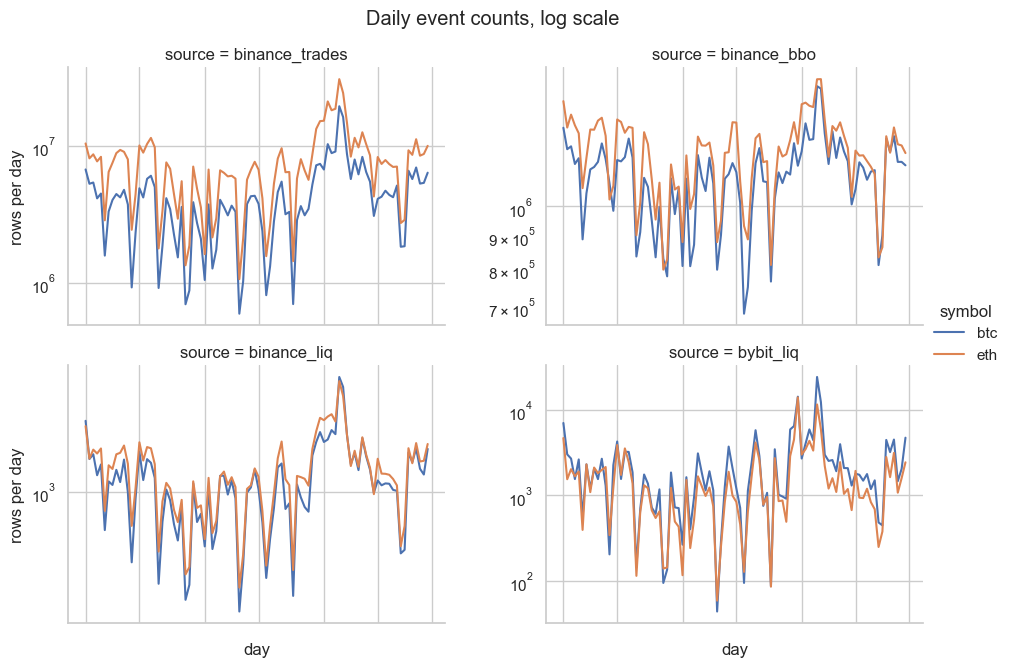

In [5]:
g = sns.relplot(
    data=daily,
    x='day', y='rows',
    hue='symbol', col='source',
    kind='line', col_wrap=2,
    facet_kws={'sharey': False},
    height=3.3, aspect=1.45,
)
g.set_xticklabels(rotation=45)
g.set_ylabels('rows per day')
for ax in g.axes.flat:
    ax.set_yscale('log')
plt.suptitle('Daily event counts, log scale', y=1.03)
plt.show()

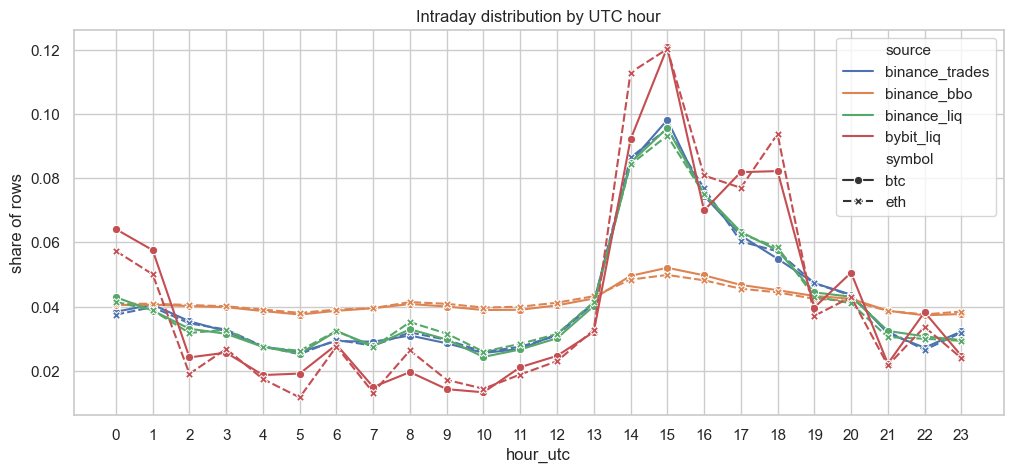

In [6]:
hourly_parts = []
for (source, symbol), path in PATHS.items():
    h = sql(f"""
        SELECT
            '{source}' AS source,
            '{symbol}' AS symbol,
            date_part('hour', make_timestamp(timestamp))::INT AS hour_utc,
            count(*) AS rows
        FROM read_parquet('{p(path)}')
        GROUP BY 1, 2, 3
        ORDER BY 3
    """)
    hourly_parts.append(h)

hourly = pd.concat(hourly_parts, ignore_index=True)
hourly['rows_share'] = hourly.groupby(['source', 'symbol'])['rows'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly, x='hour_utc', y='rows_share', hue='source', style='symbol', markers=True)
plt.title('Intraday distribution by UTC hour')
plt.ylabel('share of rows')
plt.xticks(range(24))
plt.show()

## 3. Side balance

Для trades side означает сторону тейкера. Для liquidations side означает направление принудительного ордера. Поэтому эти таблицы нельзя читать одинаково семантически, даже если колонка называется одинаково.

In [7]:
side_parts = []
for (source, symbol), path in PATHS.items():
    cols = sql(f"DESCRIBE SELECT * FROM read_parquet('{p(path)}')")['column_name'].tolist()
    if 'side' not in cols:
        continue
    s = sql(f"""
        SELECT
            '{source}' AS source,
            '{symbol}' AS symbol,
            side,
            count(*) AS rows,
            sum(price * amount) AS notional
        FROM read_parquet('{p(path)}')
        GROUP BY 1, 2, 3
        ORDER BY 1, 2, 3
    """)
    side_parts.append(s)

side_balance = pd.concat(side_parts, ignore_index=True)
side_balance['row_share'] = side_balance.groupby(['source', 'symbol'])['rows'].transform(lambda x: x / x.sum())
side_balance['notional_share'] = side_balance.groupby(['source', 'symbol'])['notional'].transform(lambda x: x / x.sum())
side_balance

,source,symbol,side,rows,notional,row_share,notional_share
0,binance_trades,btc,buy,200364106,5.9783e+11,0.498539,0.496417
1,binance_trades,btc,sell,201538407,6.06459e+11,0.501461,0.503583
2,binance_trades,eth,buy,352406724,5.45231e+11,0.499244,0.496663
3,binance_trades,eth,sell,353473661,5.52557e+11,0.500756,0.503337
4,binance_liq,btc,buy,50046,5.62097e+08,0.43802,0.435082
5,binance_liq,btc,sell,64209,7.29837e+08,0.56198,0.564918
6,binance_liq,eth,buy,58295,5.49516e+08,0.442403,0.419648
7,binance_liq,eth,sell,73474,7.59954e+08,0.557597,0.580352
8,bybit_liq,btc,buy,74857,9.99246e+08,0.32738,0.342993
9,bybit_liq,btc,sell,153798,1.91407e+09,0.67262,0.657007


## 4. Распределения: price, amount, notional

Trades очень большие, поэтому для графиков берем детерминированный сэмпл через `hash(...) % SAMPLE_MOD = 0`. Ликвидации читаем целиком: они маленькие относительно trades.

In [8]:
SAMPLE_MOD = 20_000  # roughly 0.005% deterministic sample for trades

trade_samples = []
for symbol in ['btc', 'eth']:
    path = PATHS[('binance_trades', symbol)]
    sample = sql(f"""
        SELECT
            'binance_trades' AS source,
            '{symbol}' AS symbol,
            timestamp,
            make_timestamp(timestamp) AS time_utc,
            side,
            price,
            amount,
            price * amount AS notional
        FROM read_parquet('{p(path)}')
        WHERE hash(timestamp, side, price, amount) % {SAMPLE_MOD} = 0
    """)
    trade_samples.append(sample)

liq_full = []
for source in ['binance_liq', 'bybit_liq']:
    for symbol in ['btc', 'eth']:
        path = PATHS[(source, symbol)]
        delay_us = 200_000 if source == 'bybit_liq' else 0
        liq_df = sql(f"""
            SELECT
                '{source}' AS source,
                '{symbol}' AS symbol,
                timestamp,
                timestamp + {delay_us} AS available_timestamp,
                make_timestamp(timestamp) AS time_utc,
                make_timestamp(timestamp + {delay_us}) AS available_time_utc,
                side,
                price,
                amount,
                price * amount AS notional
            FROM read_parquet('{p(path)}')
        """)
        liq_full.append(liq_df)

trade_sample = pd.concat(trade_samples, ignore_index=True)
liq = pd.concat(liq_full, ignore_index=True)

print('trade sample rows:', len(trade_sample))
print('liquidation rows:', len(liq))

trade sample rows: 55103
liquidation rows: 634893


In [9]:
def quantile_table(df, group_cols, value_cols):
    rows = []
    for keys, gdf in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        base = dict(zip(group_cols, keys))
        for col in value_cols:
            qs = gdf[col].quantile([0, .01, .05, .5, .95, .99, 1.0])
            row = base | {'metric': col}
            row.update({f'p{int(q*100):02d}': v for q, v in qs.items()})
            rows.append(row)
    return pd.DataFrame(rows)

trade_q = quantile_table(trade_sample, ['source', 'symbol'], ['price', 'amount', 'notional'])
liq_q = quantile_table(liq, ['source', 'symbol', 'side'], ['price', 'amount', 'notional'])

display(trade_q)
display(liq_q.head(30))

,source,symbol,metric,p00,p01,p05,p50,p95,p99,p100
0,binance_trades,btc,price,"59,941.9","63,179.6","64,804.7","83,516.8","93,579.8","96,237.3","97,635.9"
1,binance_trades,btc,amount,0.001,0.001,0.002,0.003,0.168,0.61992,10.828
2,binance_trades,btc,notional,60.753,67.6811,130.298,257.458,"13,510","51,377.8",1.03096e+06
3,binance_trades,eth,price,"1,737.48","1,836.55","1,900.21","2,785.26","3,284","3,361.63","3,438.04"
4,binance_trades,eth,amount,0.001,0.001,0.004,0.014,2.81025,10.151,381.735
5,binance_trades,eth,notional,1.77692,1.92978,9.78293,40.2729,"7,005.75","26,689.4","791,913"


,source,symbol,side,metric,p00,p01,p05,p50,p95,p99,p100
0,binance_liq,btc,buy,price,"60,370.2","63,493.1","65,114.4","86,191.6","94,527.2","97,222.1","98,640.2"
1,binance_liq,btc,buy,amount,0.001,0.002,0.002,0.015,0.5,2.0523,171.331
2,binance_liq,btc,buy,notional,60.5926,128.13,141.97,"1,239.32","40,377.7","162,473",1.21969e+07
3,binance_liq,btc,sell,price,"59,122.3","62,730.4","64,394.1","84,723","92,754.2","95,488.2","177,135"
4,binance_liq,btc,sell,amount,0.001,0.001,0.002,0.013,0.455,2,223
5,binance_liq,btc,sell,notional,59.7644,90.4551,138.556,"1,025.64","35,567.3","163,577",1.5055e+07
6,binance_liq,eth,buy,price,0.01,"1,853.36","1,915.48","2,908.09","3,328.57","3,389.23","3,459.49"
7,binance_liq,eth,buy,amount,0.001,0.007,0.012,0.298,11.7369,57.8591,"3,390.28"
8,binance_liq,eth,buy,notional,0.00011,20.8494,29.8061,761.028,"30,571.1","151,934",1.11694e+07
9,binance_liq,eth,sell,price,"1,736.94","1,815.98","1,881.92","2,804.59","3,254.81","3,335.07","4,095.62"


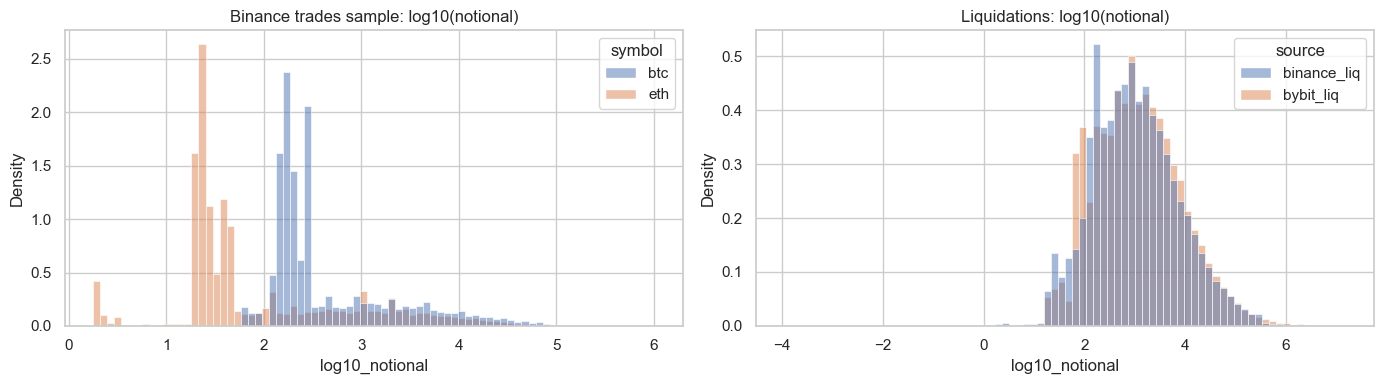

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

sns.histplot(
    data=trade_sample.assign(log10_notional=np.log10(trade_sample['notional'].clip(lower=1e-9))),
    x='log10_notional', hue='symbol', bins=80, stat='density', common_norm=False, ax=axes[0]
)
axes[0].set_title('Binance trades sample: log10(notional)')

sns.histplot(
    data=liq.assign(log10_notional=np.log10(liq['notional'].clip(lower=1e-9))),
    x='log10_notional', hue='source', bins=80, stat='density', common_norm=False, ax=axes[1]
)
axes[1].set_title('Liquidations: log10(notional)')

plt.tight_layout()
plt.show()

## 5. BBO: spread, top-of-book size, imbalance

BBO timestamps уникальные, но таблицы крупные. Для распределений используем детерминированный сэмпл по timestamp.

In [11]:
bbo_samples = []
for symbol in ['btc', 'eth']:
    path = PATHS[('binance_bbo', symbol)]
    b = sql(f"""
        SELECT
            '{symbol}' AS symbol,
            timestamp,
            make_timestamp(timestamp) AS time_utc,
            bid_price,
            ask_price,
            bid_amount,
            ask_amount,
            (bid_price + ask_price) / 2 AS mid,
            ask_price - bid_price AS spread,
            (ask_price - bid_price) / ((ask_price + bid_price) / 2) * 10000 AS spread_bps,
            (bid_amount - ask_amount) / NULLIF(bid_amount + ask_amount, 0) AS imbalance
        FROM read_parquet('{p(path)}')
        WHERE hash(timestamp) % 1000 = 0
    """)
    bbo_samples.append(b)

bbo_sample = pd.concat(bbo_samples, ignore_index=True)
print('BBO sample rows:', len(bbo_sample))

bbo_q = quantile_table(bbo_sample, ['symbol'], ['spread', 'spread_bps', 'bid_amount', 'ask_amount', 'imbalance'])
bbo_q

BBO sample rows: 206811


,symbol,metric,p00,p01,p05,p50,p95,p99,p100
0,btc,spread,0.1,0.1,0.1,0.1,0.1,0.2,57.4
1,btc,spread_bps,0.0102401,0.0103681,0.0106004,0.011386,0.0152588,0.0217745,7.55547
2,btc,bid_amount,0.001,0.008,0.144,4.291,16.6847,23.803,889.402
3,btc,ask_amount,0.001,0.007,0.137,4.165,16.6679,23.9722,829.54
4,btc,imbalance,-0.999907,-0.997544,-0.968729,0.0160525,0.969573,0.997727,0.99993
5,eth,spread,0.01,0.01,0.01,0.01,0.01,0.01,2.87
6,eth,spread_bps,0.0290446,0.0298276,0.0302471,0.0339306,0.0521675,0.0549093,9.80675
7,eth,bid_amount,0.001,0.091,1.82,60.1265,237.307,368.313,"15,450"
8,eth,ask_amount,0.001,0.10427,1.85735,59.272,233.751,369.853,"9,983.3"
9,eth,imbalance,-0.999989,-0.997911,-0.974637,0.00996496,0.974438,0.997788,0.999997


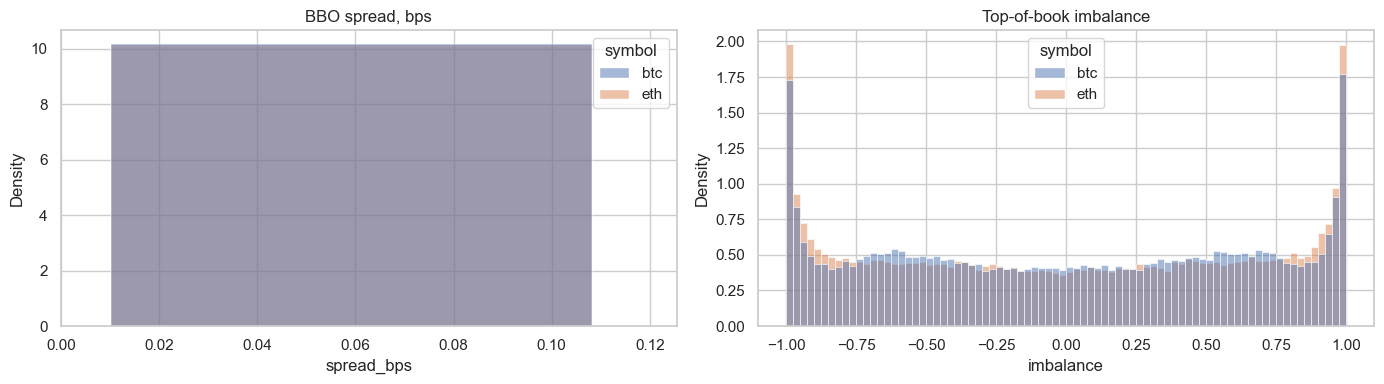

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=bbo_sample, x='spread_bps', hue='symbol', bins=100, stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('BBO spread, bps')
axes[0].set_xlim(0, bbo_sample['spread_bps'].quantile(.995))

sns.histplot(data=bbo_sample, x='imbalance', hue='symbol', bins=80, stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Top-of-book imbalance')
plt.tight_layout()
plt.show()

## 6. Дубликаты, gaps, подозрительные значения

Повторяющиеся timestamps в trades ожидаемы: в одну микросекунду может быть много fills. Но полные одинаковые строки тоже встречаются, поэтому пока не удаляем их автоматически, а фиксируем факт.

In [13]:
# Timestamp multiplicity for trades and BBO.
mult_rows = []
for source in ['binance_trades', 'binance_bbo']:
    for symbol in ['btc', 'eth']:
        path = PATHS[(source, symbol)]
        m = sql(f"""
            WITH g AS (
                SELECT timestamp, count(*) AS n
                FROM read_parquet('{p(path)}')
                GROUP BY 1
            )
            SELECT
                '{source}' AS source,
                '{symbol}' AS symbol,
                count(*) AS distinct_timestamps,
                sum(n) AS rows,
                sum(CASE WHEN n > 1 THEN n ELSE 0 END) AS rows_on_repeated_ts,
                max(n) AS max_rows_same_ts,
                approx_quantile(n, 0.99) AS p99_rows_same_ts
            FROM g
        """)
        mult_rows.append(m)

timestamp_multiplicity = pd.concat(mult_rows, ignore_index=True)
timestamp_multiplicity

,source,symbol,distinct_timestamps,rows,rows_on_repeated_ts,max_rows_same_ts,p99_rows_same_ts
0,binance_trades,btc,85036917,4.01903e+08,3.56783e+08,588,50
1,binance_trades,eth,108296437,7.0588e+08,6.51207e+08,726,72
2,binance_bbo,btc,99169477,9.91695e+07,0,1,1
3,binance_bbo,eth,107797036,1.07797e+08,0,1,1


In [14]:
# Exact duplicate full rows on the first day only, to keep this check cheap and concrete.
FIRST_DAY_START = 1764547200000000
FIRST_DAY_END = 1764633600000000

dup_rows = []
for symbol in ['btc', 'eth']:
    path = PATHS[('binance_trades', symbol)]
    d = sql(f"""
        WITH one_day AS (
            SELECT *
            FROM read_parquet('{p(path)}')
            WHERE timestamp >= {FIRST_DAY_START} AND timestamp < {FIRST_DAY_END}
        ), g AS (
            SELECT timestamp, ticker, side, price, amount, count(*) AS n
            FROM one_day
            GROUP BY 1, 2, 3, 4, 5
            HAVING count(*) > 1
        )
        SELECT
            '{symbol}' AS symbol,
            count(*) AS duplicate_groups,
            sum(n) AS rows_in_duplicate_groups,
            max(n) AS max_exact_repeats
        FROM g
    """)
    dup_rows.append(d)

exact_dups_first_day = pd.concat(dup_rows, ignore_index=True)
exact_dups_first_day

,symbol,duplicate_groups,rows_in_duplicate_groups,max_exact_repeats
0,btc,705038,1.92108e+06,175
1,eth,824630,2.38279e+06,141


In [15]:
# Suspicious liquidation prices: smallest and largest examples.
suspicious = []
for source in ['binance_liq', 'bybit_liq']:
    for symbol in ['btc', 'eth']:
        path = PATHS[(source, symbol)]
        lo = sql(f"""
            SELECT '{source}' AS source, '{symbol}' AS symbol, 'lowest_price' AS bucket,
                   make_timestamp(timestamp) AS time_utc, ticker, side, price, amount, price*amount AS notional
            FROM read_parquet('{p(path)}')
            ORDER BY price ASC
            LIMIT 5
        """)
        hi = sql(f"""
            SELECT '{source}' AS source, '{symbol}' AS symbol, 'highest_price' AS bucket,
                   make_timestamp(timestamp) AS time_utc, ticker, side, price, amount, price*amount AS notional
            FROM read_parquet('{p(path)}')
            ORDER BY price DESC
            LIMIT 5
        """)
        suspicious.extend([lo, hi])

suspicious_prices = pd.concat(suspicious, ignore_index=True)
suspicious_prices

,source,symbol,bucket,time_utc,ticker,side,price,amount,notional
0,binance_liq,btc,lowest_price,2026-02-06 00:14:31.456,perp:btcusdt,sell,"59,122.3",2.244,"132,670"
1,binance_liq,btc,lowest_price,2026-02-06 00:14:51.426,perp:btcusdt,sell,"59,169",60.614,3.58647e+06
2,binance_liq,btc,lowest_price,2026-02-06 00:19:52.340,perp:btcusdt,sell,"59,758.3",0.015,896.375
3,binance_liq,btc,lowest_price,2026-02-06 00:20:00.372,perp:btcusdt,sell,"59,764.4",0.012,717.173
4,binance_liq,btc,lowest_price,2026-02-06 00:20:01.543,perp:btcusdt,sell,"59,764.4",0.001,59.7644
5,binance_liq,btc,highest_price,2025-12-04 18:01:57.420,perp:btcusdt,sell,"177,135",0.001,177.135
6,binance_liq,btc,highest_price,2026-01-15 03:27:38.206,perp:btcusdt,sell,"103,763",0.002,207.526
7,binance_liq,btc,highest_price,2026-01-20 11:45:37.527,perp:btcusdt,sell,"99,258.4",0.002,198.517
8,binance_liq,btc,highest_price,2026-01-19 03:26:05.095,perp:btcusdt,sell,"98,867",0.003,296.601
9,binance_liq,btc,highest_price,2026-01-14 14:54:19.833,perp:btcusdt,buy,"98,640.2",0.206,"20,319.9"


## 7. Проверка конвенций на конкретных строках

Здесь не доказываем экономику сигнала, а проверяем, как читать поля.

In [16]:
# timestamp: raw microseconds -> UTC
example_ts = sql(f"""
    SELECT timestamp, make_timestamp(timestamp) AS time_utc
    FROM read_parquet('{p(PATHS[('binance_trades', 'btc')])}')
    LIMIT 3
""")
example_ts

,timestamp,time_utc
0,1764547200047000,2025-12-01 00:00:00.047
1,1764547200047000,2025-12-01 00:00:00.047
2,1764547200047000,2025-12-01 00:00:00.047


In [17]:
# Liquidation side examples and Bybit +200ms availability time.
liq_examples = []
for source in ['binance_liq', 'bybit_liq']:
    for symbol in ['btc', 'eth']:
        path = PATHS[(source, symbol)]
        delay_us = 200_000 if source == 'bybit_liq' else 0
        e = sql(f"""
            SELECT
                '{source}' AS source,
                '{symbol}' AS symbol,
                timestamp,
                make_timestamp(timestamp) AS event_time_utc,
                timestamp + {delay_us} AS available_timestamp,
                make_timestamp(timestamp + {delay_us}) AS available_time_utc,
                side,
                CASE
                    WHEN side = 'buy' THEN 'forced buy: short liquidation, upward pressure'
                    WHEN side = 'sell' THEN 'forced sell: long liquidation, downward pressure'
                END AS interpretation,
                price,
                amount,
                price * amount AS notional
            FROM read_parquet('{p(path)}')
            QUALIFY row_number() OVER (PARTITION BY side ORDER BY timestamp) = 1
            ORDER BY side
        """)
        liq_examples.append(e)

liq_side_examples = pd.concat(liq_examples, ignore_index=True)
liq_side_examples

,source,symbol,timestamp,event_time_utc,available_timestamp,available_time_utc,side,interpretation,price,amount,notional
0,binance_liq,btc,1764547544157000,2025-12-01 00:05:44.157,1764547544157000,2025-12-01 00:05:44.157,buy,"forced buy: short liquidation, upward pressure","89,887.9",0.029,"2,606.75"
1,binance_liq,btc,1764547206091000,2025-12-01 00:00:06.091,1764547206091000,2025-12-01 00:00:06.091,sell,"forced sell: long liquidation, downward pressure","89,936",0.014,"1,259.1"
2,binance_liq,eth,1764547254412000,2025-12-01 00:00:54.412,1764547254412000,2025-12-01 00:00:54.412,buy,"forced buy: short liquidation, upward pressure","3,008.76",7.899,"23,766.2"
3,binance_liq,eth,1764547209455000,2025-12-01 00:00:09.455,1764547209455000,2025-12-01 00:00:09.455,sell,"forced sell: long liquidation, downward pressure","2,977.61",0.055,163.769
4,bybit_liq,btc,1764547450688000,2025-12-01 00:04:10.688,1764547450888000,2025-12-01 00:04:10.888,buy,"forced buy: short liquidation, upward pressure","89,970.9",0.003,269.913
5,bybit_liq,btc,1764547202915000,2025-12-01 00:00:02.915,1764547203115000,2025-12-01 00:00:03.115,sell,"forced sell: long liquidation, downward pressure","89,838.9",0.032,"2,874.84"
6,bybit_liq,eth,1764547451436000,2025-12-01 00:04:11.436,1764547451636000,2025-12-01 00:04:11.636,buy,"forced buy: short liquidation, upward pressure","2,995.76",0.83,"2,486.48"
7,bybit_liq,eth,1764547207779000,2025-12-01 00:00:07.779,1764547207979000,2025-12-01 00:00:07.979,sell,"forced sell: long liquidation, downward pressure","2,973.27",0.15,445.99


## 8. Mini event-study вокруг крупных liquidation bursts

Берем крупнейшие 1-second buckets по liquidation notional. Для Bybit сначала применяем `+200ms`, потом округляем к секунде доступности. Смотрим, куда сдвинулся Binance mid через 30s и 120s.

Это грубая диагностика, не финальный сигнал: bucket по секундам теряет часть точности, зато быстро показывает направление и масштаб эффекта.

In [18]:
def liquidation_burst_study(source, symbol, top_n=300):
    liq_path = PATHS[(source, symbol)]
    bbo_path = PATHS[('binance_bbo', symbol)]
    delay_us = 200_000 if source == 'bybit_liq' else 0
    return sql(f"""
        WITH liq_sec AS (
            SELECT
                ((timestamp + {delay_us}) // 1000000) * 1000000 AS event_sec_us,
                side,
                count(*) AS n_liq,
                sum(price * amount) AS liq_notional
            FROM read_parquet('{p(liq_path)}')
            GROUP BY 1, 2
        ), top_events AS (
            SELECT
                '{source}' AS source,
                '{symbol}' AS symbol,
                event_sec_us,
                make_timestamp(event_sec_us) AS event_sec_utc,
                side,
                n_liq,
                liq_notional
            FROM liq_sec
            ORDER BY liq_notional DESC
            LIMIT {top_n}
        ), targets AS (
            SELECT *, 't0' AS horizon, event_sec_us AS target_ts FROM top_events
            UNION ALL SELECT *, 't30s' AS horizon, event_sec_us + 30*1000000 AS target_ts FROM top_events
            UNION ALL SELECT *, 't120s' AS horizon, event_sec_us + 120*1000000 AS target_ts FROM top_events
        ), bbo AS (
            SELECT timestamp AS bbo_ts, (bid_price + ask_price) / 2 AS mid
            FROM read_parquet('{p(bbo_path)}')
        )
        SELECT
            t.source, t.symbol, t.event_sec_us, t.event_sec_utc, t.side,
            t.n_liq, t.liq_notional, t.horizon, b.bbo_ts, b.mid
        FROM targets t ASOF LEFT JOIN bbo b
          ON t.target_ts >= b.bbo_ts
    """)

burst_parts = []
for source in ['binance_liq', 'bybit_liq']:
    for symbol in ['btc', 'eth']:
        burst_parts.append(liquidation_burst_study(source, symbol, top_n=300))

burst_long = pd.concat(burst_parts, ignore_index=True)
burst = (
    burst_long
    .pivot_table(
        index=['source', 'symbol', 'event_sec_us', 'event_sec_utc', 'side', 'n_liq', 'liq_notional'],
        columns='horizon', values='mid', aggfunc='first'
    )
    .reset_index()
)
burst.columns.name = None
burst['ret_30s_bps'] = (burst['t30s'] - burst['t0']) / burst['t0'] * 10_000
burst['ret_120s_bps'] = (burst['t120s'] - burst['t0']) / burst['t0'] * 10_000

burst_summary = (
    burst.groupby(['source', 'symbol', 'side'])
    .apply(lambda g: pd.Series({
        'events': len(g),
        'median_notional': g['liq_notional'].median(),
        'wavg_ret_30s_bps': np.average(g['ret_30s_bps'], weights=g['liq_notional']),
        'wavg_ret_120s_bps': np.average(g['ret_120s_bps'], weights=g['liq_notional']),
        'median_ret_30s_bps': g['ret_30s_bps'].median(),
        'median_ret_120s_bps': g['ret_120s_bps'].median(),
    }))
    .reset_index()
)

burst_summary

,source,symbol,side,events,median_notional,wavg_ret_30s_bps,wavg_ret_120s_bps,median_ret_30s_bps,median_ret_120s_bps
0,binance_liq,btc,buy,119,"608,678",-3.17428,-1.66251,-0.786993,-2.43215
1,binance_liq,btc,sell,181,"698,205",-6.05583,-2.93003,-0.405688,1.66499
2,binance_liq,eth,buy,129,"705,699",8.22916,31.5455,-1.87195,-3.11549
3,binance_liq,eth,sell,171,"787,272",1.96918,29.7123,0.253746,4.24181
4,bybit_liq,btc,buy,88,2.04949e+06,2.00433,-13.4594,0.466607,-4.01504
5,bybit_liq,btc,sell,212,2.08537e+06,2.92666,22.8245,2.00835,9.34926
6,bybit_liq,eth,buy,82,1.03701e+06,11.1524,9.25525,-3.95377,0.843817
7,bybit_liq,eth,sell,218,1.11002e+06,5.18231,52.3768,4.04402,23.5175


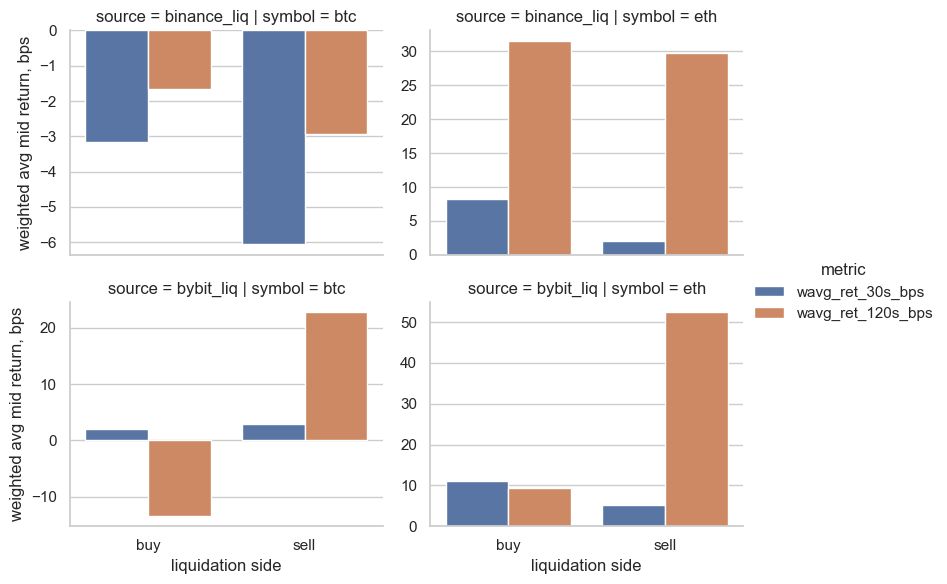

In [19]:
plot_df = burst_summary.melt(
    id_vars=['source', 'symbol', 'side'],
    value_vars=['wavg_ret_30s_bps', 'wavg_ret_120s_bps'],
    var_name='metric', value_name='bps'
)

g = sns.catplot(
    data=plot_df,
    x='side', y='bps', hue='metric', col='symbol', row='source',
    kind='bar', height=3, aspect=1.3, sharey=False
)
g.set_axis_labels('liquidation side', 'weighted avg mid return, bps')
plt.show()

## 9. Trade markout на маленьком sample

Это не модель, но полезный мост к будущей задаче: считаем maker PnL по формуле из описания на детерминированном sample trades. Здесь важно помнить: если `trade.side = buy`, тейкер купил, значит maker продал.

In [20]:
def sampled_trade_markout(symbol, sample_mod=20_000):
    trade_path = PATHS[('binance_trades', symbol)]
    bbo_path = PATHS[('binance_bbo', symbol)]
    return sql(f"""
        WITH bbo_bounds AS (
            SELECT max(timestamp) AS max_bbo_ts
            FROM read_parquet('{p(bbo_path)}')
        ), trades AS (
            SELECT
                '{symbol}' AS symbol,
                timestamp AS trade_ts,
                make_timestamp(timestamp) AS trade_time_utc,
                side,
                price,
                amount,
                price * amount AS notional,
                least(price * amount, 100000.0) AS w,
                CASE WHEN side = 'buy' THEN 1 ELSE -1 END AS s
            FROM read_parquet('{p(trade_path)}'), bbo_bounds
            WHERE hash(timestamp, side, price, amount) % {sample_mod} = 0
              AND timestamp + 300*1000000 <= max_bbo_ts
        ), targets AS (
            SELECT *, 30 AS horizon_s, trade_ts + 30*1000000 AS target_ts FROM trades
            UNION ALL SELECT *, 120 AS horizon_s, trade_ts + 120*1000000 AS target_ts FROM trades
            UNION ALL SELECT *, 300 AS horizon_s, trade_ts + 300*1000000 AS target_ts FROM trades
        ), bbo AS (
            SELECT timestamp AS bbo_ts, (bid_price + ask_price) / 2 AS mid
            FROM read_parquet('{p(bbo_path)}')
        )
        SELECT
            t.symbol, t.trade_ts, t.trade_time_utc, t.side, t.price, t.amount,
            t.notional, t.w, t.s, t.horizon_s, b.bbo_ts, b.mid,
            (-t.s * (b.mid - t.price) / t.price * 10000 + 0.5) AS maker_pnl_bps
        FROM targets t ASOF LEFT JOIN bbo b
          ON t.target_ts >= b.bbo_ts
    """)

markout = pd.concat([sampled_trade_markout('btc'), sampled_trade_markout('eth')], ignore_index=True)
print('sample markout rows:', len(markout))
markout.head()

sample markout rows: 165306


,symbol,trade_ts,trade_time_utc,side,price,amount,notional,w,s,horizon_s,bbo_ts,mid,maker_pnl_bps
0,btc,1764547208650000,2025-12-01 00:00:08.650,buy,"90,263.3",0.014,"1,263.69","1,263.69",1,30,1764547238613000,"90,318.8",-5.64314
1,btc,1764547208650000,2025-12-01 00:00:08.650,buy,"90,263.3",0.014,"1,263.69","1,263.69",1,120,1764547328609000,"90,289.1",-2.35277
2,btc,1764547415220000,2025-12-01 00:03:35.220,buy,"90,166.4",0.003,270.499,270.499,1,30,1764547445190000,"90,067.1",11.513
3,btc,1764547415220000,2025-12-01 00:03:35.220,buy,"90,166.4",0.003,270.499,270.499,1,30,1764547445190000,"90,067.1",11.513
4,btc,1764547415220000,2025-12-01 00:03:35.220,buy,"90,166.4",0.003,270.499,270.499,1,30,1764547445190000,"90,067.1",11.513


In [21]:
markout_summary = (
    markout.dropna(subset=['maker_pnl_bps'])
    .groupby(['symbol', 'side', 'horizon_s'])
    .apply(lambda g: pd.Series({
        'rows': len(g),
        'turnover_sample': g['w'].sum(),
        'weighted_pnl_bps': np.average(g['maker_pnl_bps'], weights=g['w']),
        'median_pnl_bps': g['maker_pnl_bps'].median(),
        'p05_pnl_bps': g['maker_pnl_bps'].quantile(.05),
        'p95_pnl_bps': g['maker_pnl_bps'].quantile(.95),
    }))
    .reset_index()
)
markout_summary

,symbol,side,horizon_s,rows,turnover_sample,weighted_pnl_bps,median_pnl_bps,p05_pnl_bps,p95_pnl_bps
0,btc,buy,30,"10,036",2.73213e+07,-0.314462,0.130799,-14.1883,14.287
1,btc,buy,120,"10,036",2.73213e+07,0.16914,-0.0536542,-26.495,27.8561
2,btc,buy,300,"10,036",2.73213e+07,1.35019,0.372271,-41.5697,44.0333
3,btc,sell,30,"9,991",2.78669e+07,0.00658093,-0.128202,-14.4683,14.0797
4,btc,sell,120,"9,991",2.78669e+07,0.441534,-0.280629,-28.4225,26.0378
5,btc,sell,300,"9,991",2.78669e+07,0.512574,-0.386573,-46.5142,39.5767
6,eth,buy,30,"17,523",2.48754e+07,0.311807,-0.0169286,-21.0776,19.4703
7,eth,buy,120,"17,523",2.48754e+07,-0.284766,0.0839989,-38.2757,37.2369
8,eth,buy,300,"17,523",2.48754e+07,0.717285,0.1435,-56.4584,59.7947
9,eth,sell,30,"17,552",2.51335e+07,0.10907,-0.202386,-20.2618,19.5877


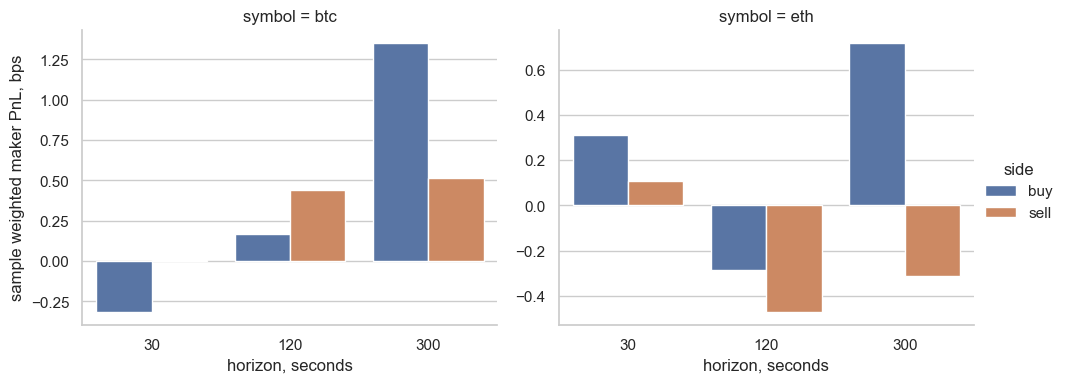

In [22]:
g = sns.catplot(
    data=markout_summary,
    x='horizon_s', y='weighted_pnl_bps', hue='side', col='symbol',
    kind='bar', height=4, aspect=1.25, sharey=False
)
g.set_axis_labels('horizon, seconds', 'sample weighted maker PnL, bps')
plt.show()

## 10. Первые вопросы после осмотра

Что кажется перспективным для следующего исследовательского прохода:

1. Сравнить markout trades после крупных same-side liquidation bursts vs обычные trades.
2. Проверить, дает ли Bybit после `+200ms` независимый сигнал или просто дублирует уже видимое на Binance.
3. Разделить ликвидации по notional percentile, а не по абсолютным dollar thresholds.
4. Смотреть не только факт ликвидации, но и cluster features: count, sum notional, buy/sell imbalance за последние `1s/5s/30s/120s`.
5. Для BBO проверить, усиливают ли spread widening и top-of-book imbalance токсичность сделки.
6. Отдельно решить политику по странным liquidation prices: не удалять молча, а использовать robust clipping и флаги outlier.


## 11. Cross-exchange связь: Bybit -> Binance

Здесь проверяем не price prediction, а более базовый вопрос: совпадают ли ликвидационные события Bybit и Binance на одной временной оси.

Метод:

- агрегируем liquidation notional по секундам и `side`;
- для Bybit сначала применяем `+200ms`, как требует описание;
- смотрим, насколько часто после Bybit liquidation second есть Binance liquidation same-side;
- считаем cross-correlation секундных рядов `log1p(notional)` по лагам. Positive lag означает: Binance идет после Bybit.


In [23]:

liq_sec_parts = []
for exchange in ['binance', 'bybit']:
    for symbol in ['btc', 'eth']:
        path = PATHS[(f'{exchange}_liq', symbol)]
        delay_us = 200_000 if exchange == 'bybit' else 0
        d = sql(f"""
            SELECT
                '{exchange}' AS exchange,
                '{symbol}' AS symbol,
                ((timestamp + {delay_us}) // 1000000)::BIGINT AS sec,
                side,
                count(*) AS n,
                sum(price * amount) AS notional
            FROM read_parquet('{p(path)}')
            GROUP BY 1, 2, 3, 4
        """)
        liq_sec_parts.append(d)

liq_sec = pd.concat(liq_sec_parts, ignore_index=True)
liq_sec.head(), len(liq_sec)


(  exchange symbol         sec  side  n  notional
 0  binance    btc  1764547209  sell  1  4,316.39
 1  binance    btc  1764547223  sell  1   179.813
 2  binance    btc  1764547315  sell  1   809.155
 3  binance    btc  1764547326  sell  1  1,887.65
 4  binance    btc  1764547438  sell  1     2,245,
 356415)

In [24]:

# Bybit second -> Binance same-side liquidation windows.
# This is a conditional overlap table, not a causal estimate.
overlap_rows = []
for symbol in ['btc', 'eth']:
    for side in ['buy', 'sell']:
        byb = liq_sec[(liq_sec.exchange == 'bybit') & (liq_sec.symbol == symbol) & (liq_sec.side == side)].copy()
        bin_same = liq_sec[(liq_sec.exchange == 'binance') & (liq_sec.symbol == symbol) & (liq_sec.side == side)]
        bin_opp = liq_sec[(liq_sec.exchange == 'binance') & (liq_sec.symbol == symbol) & (liq_sec.side != side)]
        same_map = dict(zip(bin_same.sec.astype(int), bin_same.notional.astype(float)))
        opp_map = dict(zip(bin_opp.sec.astype(int), bin_opp.notional.astype(float)))
        thresholds = {
            'all_bybit_seconds': -np.inf,
            'top_10pct_bybit_seconds': byb.notional.quantile(.90),
            'top_1pct_bybit_seconds': byb.notional.quantile(.99),
            'top_500_bybit_seconds': byb.notional.nlargest(min(500, len(byb))).min(),
        }
        for bucket, threshold in thresholds.items():
            events = byb[byb.notional >= threshold]
            vals = []
            for event_sec in events.sec.astype(int).to_numpy():
                same_pre5 = sum(same_map.get(t, 0.0) for t in range(event_sec - 5, event_sec))
                same_post5 = sum(same_map.get(t, 0.0) for t in range(event_sec, event_sec + 6))
                same_post30 = sum(same_map.get(t, 0.0) for t in range(event_sec, event_sec + 31))
                opp_post5 = sum(opp_map.get(t, 0.0) for t in range(event_sec, event_sec + 6))
                vals.append((same_pre5, same_post5, same_post30, opp_post5))
            arr = np.asarray(vals, dtype=float)
            overlap_rows.append({
                'symbol': symbol,
                'side': side,
                'bucket': bucket,
                'events': len(events),
                'bybit_median_notional': events.notional.median(),
                'bin_same_pre5_avg': arr[:, 0].mean(),
                'bin_same_post5_avg': arr[:, 1].mean(),
                'bin_same_post30_avg': arr[:, 2].mean(),
                'bin_opp_post5_avg': arr[:, 3].mean(),
                'share_bin_same_post5_gt0': (arr[:, 1] > 0).mean(),
                'share_bin_same_post30_gt0': (arr[:, 2] > 0).mean(),
            })

overlap = pd.DataFrame(overlap_rows)
overlap


,symbol,side,bucket,events,bybit_median_notional,bin_same_pre5_avg,bin_same_post5_avg,bin_same_post30_avg,bin_opp_post5_avg,share_bin_same_post5_gt0,share_bin_same_post30_gt0
0,btc,buy,all_bybit_seconds,24794,"3,206.64","19,414.6","32,508.7","79,177.6","2,149.76",0.810559,0.881544
1,btc,buy,top_10pct_bybit_seconds,2480,"158,969","34,217","63,561.9","147,450",275.775,0.953226,0.97621
2,btc,buy,top_1pct_bybit_seconds,248,1.27295e+06,"25,504.7","89,942.4","159,932",93.1691,0.96371,0.987903
3,btc,buy,top_500_bybit_seconds,500,"681,398","31,555.3","70,789.4","155,720",46.2119,0.972,0.99
4,btc,sell,all_bybit_seconds,34088,"3,468.86","24,881.7","35,569.9","100,100",567.542,0.84848,0.907005
5,btc,sell,top_10pct_bybit_seconds,3409,"225,948","60,242","91,241.9","257,357",890.53,0.975066,0.987386
6,btc,sell,top_1pct_bybit_seconds,341,1.83951e+06,"110,579","130,971","344,873","1,769.39",0.98827,0.997067
7,btc,sell,top_500_bybit_seconds,500,1.48091e+06,"104,399","115,884","372,450","1,270.17",0.986,0.994
8,eth,buy,all_bybit_seconds,20332,"2,023.72","20,665.1","32,761.3","80,008.1","1,213.61",0.84458,0.905617
9,eth,buy,top_10pct_bybit_seconds,2034,"102,657","29,245.9","73,360.9","165,476",474.907,0.95821,0.979351


In [25]:

# Cross-correlation of second-level log1p liquidation notionals.
# positive lag_sec = Binance series is shifted after Bybit.
cc_rows = []
for symbol in ['btc', 'eth']:
    min_sec = int(liq_sec[liq_sec.symbol == symbol].sec.min())
    max_sec = int(liq_sec[liq_sec.symbol == symbol].sec.max())
    length = max_sec - min_sec + 1
    for side in ['buy', 'sell']:
        series = {}
        for exchange in ['bybit', 'binance']:
            x = np.zeros(length, dtype=np.float32)
            sub = liq_sec[(liq_sec.exchange == exchange) & (liq_sec.symbol == symbol) & (liq_sec.side == side)]
            idx = sub.sec.astype(int).to_numpy() - min_sec
            x[idx] = np.log1p(sub.notional.to_numpy(dtype=float))
            series[exchange] = x
        byb = series['bybit']
        binance = series['binance']
        for lag_sec in range(-30, 31):
            if lag_sec < 0:
                a, b = byb[-lag_sec:], binance[:lag_sec]
            elif lag_sec > 0:
                a, b = byb[:-lag_sec], binance[lag_sec:]
            else:
                a, b = byb, binance
            corr = np.corrcoef(a, b)[0, 1]
            cc_rows.append({
                'symbol': symbol,
                'side': side,
                'lag_sec': lag_sec,
                'corr_log1p_notional': corr,
            })

cc = pd.DataFrame(cc_rows)
cc_top_lags = cc.sort_values('corr_log1p_notional', ascending=False).groupby(['symbol', 'side']).head(8)
cc_top_lags


,symbol,side,lag_sec,corr_log1p_notional
92,btc,sell,1,0.390089
214,eth,sell,1,0.357646
91,btc,sell,0,0.355142
30,btc,buy,0,0.348913
31,btc,buy,1,0.344883
93,btc,sell,2,0.335291
213,eth,sell,0,0.326404
153,eth,buy,1,0.31375
215,eth,sell,2,0.307737
152,eth,buy,0,0.304261


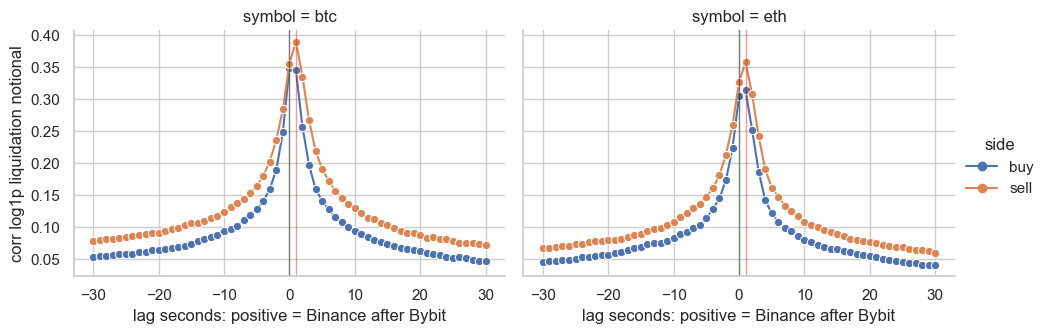

In [26]:

g = sns.relplot(
    data=cc,
    x='lag_sec', y='corr_log1p_notional',
    hue='side', col='symbol',
    kind='line', marker='o', height=3.5, aspect=1.4,
)
for ax in g.axes.flat:
    ax.axvline(0, color='black', linewidth=1, alpha=.4)
    ax.axvline(1, color='red', linewidth=1, alpha=.4)
g.set_axis_labels('lag seconds: positive = Binance after Bybit', 'corr log1p liquidation notional')
plt.show()



Первичная интерпретация:

- Связь Bybit/Binance по ликвидациям видна сильно: максимум корреляции обычно на `0s` или `+1s`, где `+1s` значит Binance после Bybit.
- Для крупных Bybit seconds почти всегда есть Binance same-side liquidation рядом: в top buckets доля `post_5s > 0` обычно около `97-99%`.
- Это не значит, что Bybit дает чистый directional price signal. В event-study выше видно, что после крупных liquidation bursts часто появляется reversal, особенно на горизонте `120s`.
- Поэтому для будущих фичей Bybit лучше читать как индикатор stress/liquidation cascade, а не как простое правило `buy -> вверх`, `sell -> вниз`.



## 12. Weird anomalies found so far

Наблюдения после отдельного anomaly pass:

1. **Timestamp хранится в микросекундах, но фактическая точность миллисекундная.** Во всех таблицах `timestamp % 1000 == 0`. Значит внутри одной миллисекунды порядок событий не восстановить.

2. **BBO выглядит как ~20Hz sampled stream, а не каждый book update.** Для BTC/ETH `min_dt_us` около `51_000`, median около `52_000`; максимум в секунду около 20 обновлений. Это важно для markout и event-study: forward-fill BBO может быть грубее, чем кажется.

3. **В BBO есть data gaps до нескольких минут.** Крупнейшие gaps:
   - BTC BBO: `2026-02-26 13:29:45.147 -> 13:33:04.488`, gap `199.341s`;
   - ETH BBO: `2025-12-22 02:06:07.895 -> 02:12:01.902`, gap `354.007s`.
   Формально forward-fill разрешен, но near-gap markout надо помечать флагом stale BBO.

4. **BBO не crossed/locked, но бывают огромные spread spikes.**
   - BTC max spread `298.2`, около `33.7 bps`, `2025-12-14 11:44:46.183`;
   - ETH max spread `34.9`, около `119 bps`, `2025-12-07 14:25:19.349`;
   - ETH spread bps max около `130 bps`, `2026-01-31 18:43:16`.

5. **Binance liquidation feed выглядит throttled / sparse.** В Binance liquidations максимум 1 row на секунду, median gap между liquidation rows около `4s`, min gap около `0.8-0.95s`. Bybit, наоборот, имеет сотни liquidation rows в одну секунду. Значит `count` Binance liquidation и `count` Bybit liquidation нельзя сравнивать напрямую.

6. **Bybit liquidation bursts реально дикие.** Например BTC Bybit после `+200ms` bucket `2026-01-31 18:43:34` содержит `387` liquidation rows и `7.69M` notional за одну секунду. ETH Bybit `2026-02-06 00:19:49` содержит `188` rows и `7.42M` notional.

7. **Есть явные bad-price / tiny-notional liquidation outliers на Binance.**
   - Binance ETH liquidation `2025-12-23 13:37:02.642`: `price=0.01`, mid около `2935.915`, то есть почти `-10000 bps` от mid, notional `0.00011`.
   - Binance BTC liquidation `2025-12-04 18:01:57.420`: `price=177134.7`, mid около `92243.35`, то есть `+9203 bps` от mid, notional всего `$177`.
   - Binance ETH max price `4095.62` при mid около `2344.175`, notional всего `$16`.
   Эти лучше не использовать как price signal; для liquidation features безопаснее агрегировать clipped/robust notional и добавить outlier flags.

8. **Крупные liquidation notionals могут быть далеко от mid, но это уже похоже на настоящий стресс, а не просто мусор.** Например Binance ETH max-notional liquidation `2026-01-31 18:43:51.269` на `$15.5M` была примерно `-148 bps` от Binance mid.

9. **Самые плотные trade seconds совпадают со стрессовыми моментами.** ETH `2026-01-31 18:43:13` имеет `21,793` trades и `$216M` notional за одну секунду; это тот же район, где всплывают spread spikes и Bybit liquidation bursts.

Практический вывод: для будущего сигнала нужны флаги качества данных: stale BBO, huge spread, liquidation price outlier, Bybit burst percentile, а не только сырые `side/amount/price`.
